# Make Decisions with Confidence
**Hamed Seyed-Allaei**

Most ML evaluation pipelines hand you a single number — precision = 0.873, recall = 0.612, AUC = 0.94 — and walk away. Those numbers are point estimates. Run the same model on a slightly different test set and you'd get different numbers. How different? That's the question a single number can't answer.

This notebook shows a vectorized PySpark recipe for putting confidence intervals on **any** classifier metric, by bootstrapping the test set. Precision–recall curves with confidence bands are the demo, not the point — the same machinery gives you CIs on AUC, F1, calibration error, or anything else you compute groupby `replica`.

**Why PySpark?** Because at production scale (10⁷–10⁹ test rows, many models, stratified by country / segment / time window), a Python loop over `sklearn.utils.resample` takes hours. The functions here process all models × all replicas × all groups in one distributed pass.

## The workflow

1. Get predictions from each model, label them with a `name` column, concatenate into one dataframe.
2. Bootstrap: resample the rows with replacement, many times, each iteration tagged with a `replica` id. Replica `-1` is reserved for the original (un-resampled) data.
3. Compute whatever metrics you want, grouped by `['replica', 'name', …]`.
4. Look at the distribution of each metric across replicas — that's your confidence interval.

## Two things to know up front

**Spark is lazy, and that's a problem for bootstrap.** A naive implementation builds a deferred plan, then every terminal action re-rolls the random dice — meaning the "replica 7" you used to compute precision is not the same "replica 7" you used to compute recall. Recall ends up greater than 1, joins between metrics go haywire, replica IDs become meaningless. The fix is `checkpoint()`, which materializes the resampled data once. The code below does this explicitly; the comments explain why.

**Bootstrap underestimates uncertainty.** The true CI is usually a bit wider than the bootstrap CI. Treat the bands as a lower bound on how much you should worry.

## Bootstrap in one minute

Bootstrap estimates how reliable a number is by repeatedly creating new datasets via resampling the original with replacement, then recomputing the number on each. The spread across recomputations tells you how much randomness in your test set could have moved the number.

It is a black box: works for any statistic, no distributional assumptions. The catch — it is only as good as your original data. Biased data gives biased CIs.

In [ ]:
# skip this cell, only for demonstration.
# Functions to make plots to demonstate bootstraping steps,
# and show what confidence interval is.

import numpy as np
import matplotlib.pyplot as plt

def plot_steps():
    # 1. Original Sample
    np.random.seed(42)
    # Create a small sample for visualization clarity
    original_sample = np.random.normal(loc=10, scale=2, size=10)
    original_mean = np.mean(original_sample)

    # 2. Setup for plotting multiple steps in a grid
    fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True) # 1 subplot for original, 3 for bootstrap steps

    # Plot Original Sample
    ax = axes[0]
    ax.scatter(original_sample, np.random.normal(size=original_sample.shape[0], scale=0.01), s=100, alpha=0.5, color='blue', edgecolor='black')
    ax.set_title(f'Step 1: Original Sample (n={len(original_sample)})', fontsize=14)
    ax.text(np.mean(original_sample), 0.1, f'Mean: {original_mean:.2f}', color='red', fontsize=12, ha='center')
    ax.set_yticks([]) # Hide y-axis
    ax.set_ylim(-0.2, 0.2)
    ax.axvline(original_mean, color='red', linestyle='dashed', linewidth=1)
    ax.grid(axis='x', linestyle='--', alpha=0.6)

    # Plot a few Bootstrap Samples
    num_bootstrap_examples = 3
    for i in range(num_bootstrap_examples):
        # Resample with replacement
        bootstrap_sample = np.random.choice(original_sample, size=len(original_sample), replace=True)
        bootstrap_mean = np.mean(bootstrap_sample)

        ax = axes[i + 1]
        ax.scatter(bootstrap_sample, np.random.normal(size=bootstrap_sample.shape[0], scale=0.01), s=100, alpha=0.5, color='green', edgecolor='black')
        ax.set_title(f'Step {i+2}: Bootstrap Sample {i+1} (Resampled with Replacement)', fontsize=14)
        ax.text(np.mean(bootstrap_sample), 0.1, f'Mean: {bootstrap_mean:.2f}', color='purple', fontsize=12, ha='center')
        ax.set_yticks([]) # Hide y-axis
        ax.set_ylim(-0.2, 0.2)
        ax.axvline(bootstrap_mean, color='purple', linestyle='dashed', linewidth=1)
        ax.grid(axis='x', linestyle='--', alpha=0.6)

    plt.xlabel('Data Value', fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_ci():
    # 1. Create a sample dataset
    np.random.seed(42)
    original_sample = np.random.normal(loc=10, scale=2, size=50)
    original_mean = np.mean(original_sample)

    # 2. Implement the simple bootstrap process
    num_bootstrap_samples = 5000
    bootstrap_means = []

    for _ in range(num_bootstrap_samples):
        bootstrap_sample = np.random.choice(original_sample, size=len(original_sample), replace=True)
        bootstrap_means.append(np.mean(bootstrap_sample))

    # 3. Calculate confidence interval
    # For a 95% confidence interval, we find the 2.5th and 97.5th percentiles
    alpha = 0.05
    lower_bound = np.percentile(bootstrap_means, 100 * alpha / 2)
    upper_bound = np.percentile(bootstrap_means, 100 * (1 - alpha / 2))

    # 4. Visualize the distribution of the bootstrap means with confidence interval
    plt.figure(figsize=(10, 6))
    plt.hist(bootstrap_means, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black', label='Bootstrap Mean Distribution')
    plt.axvline(original_mean, color='red', linestyle='dashed', linewidth=2, label=f'Original Sample Mean: {original_mean:.2f}')
    plt.axvline(lower_bound, color='green', linestyle='dotted', linewidth=2, label=f'95% CI Lower Bound: {lower_bound:.2f}')
    plt.axvline(upper_bound, color='green', linestyle='dotted', linewidth=2, label=f'95% CI Upper Bound: {upper_bound:.2f}')
    plt.title('Distribution of Bootstrap Sample Means with 95% Confidence Interval')
    plt.xlabel('Sample Mean')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show() # Use plt.show() to display the plot if not saving to file
    # plt.savefig('bootstrap_mean_distribution_ci.png') # Uncomment to save the plot

### The resampling step

Pick rows from your original data at random, with replacement (some rows appear twice, some not at all). Repeat to get many bootstrap samples, each the same size as the original. Compute your statistic on each.

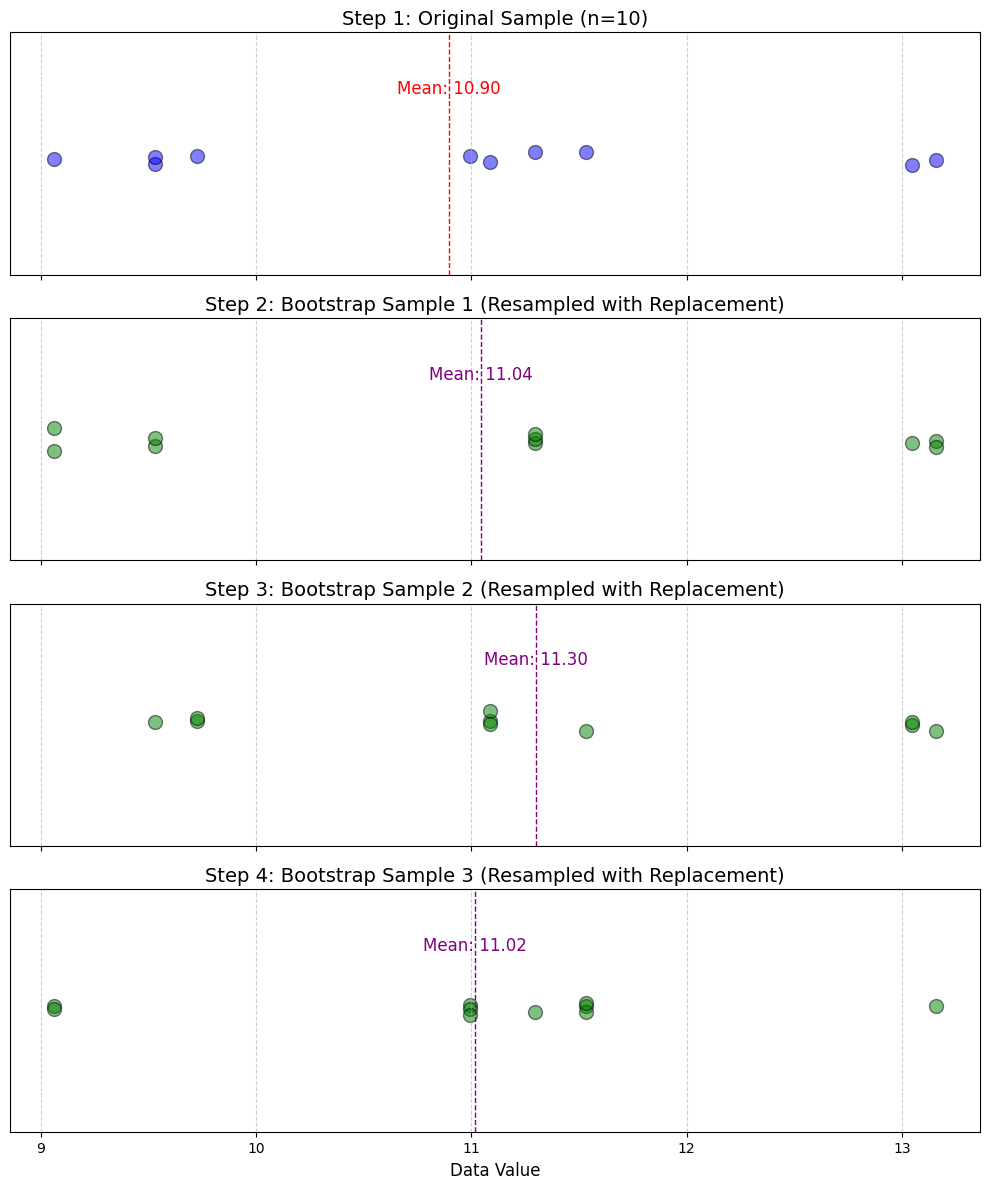

In [ ]:
plot_steps()

### From samples to confidence intervals

The distribution of the recomputed statistic across bootstrap samples gives you a confidence interval. A 95% CI runs from the 2.5th to 97.5th percentile of that distribution.

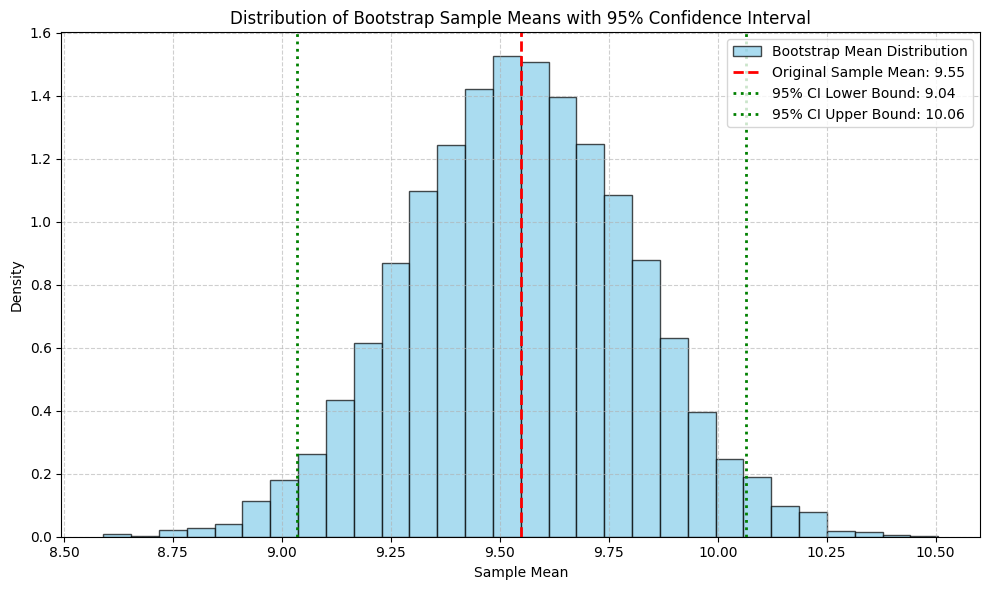

In [ ]:
plot_ci()

## Setup

In [ ]:
import pyspark.sql.types as T
import pyspark.sql.functions as F
from pyspark.sql.window import Window

import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("MakeDecisionsWithConfidence").getOrCreate()

## The bootstrap functions

These are the two functions that do the resampling. Everything downstream is just `groupBy('replica').agg(...)` on the output.

### `sample` — resample one replica

Resamples rows with replacement, optionally within strata. The strata matter under class imbalance: without stratification, a rare-class replica might have zero positives and your metric becomes undefined.

**No seed.** This is deliberate. The function is called inside a Python loop, once per replica. If the seed were fixed, every loop iteration would produce the *same* "random" sample and all your replicas would collapse to one. You want different draws per iteration, which means no seed.

If you need reproducibility across notebook runs, set Spark's RNG at the SparkContext level — but within a single run, the lack of a per-call seed is what makes the replicas actually different.

In [ ]:
def sample(df, by, fraction=1.0):
    """
    Sample with replacement within each group of a DataFrame.

    Parameters
    ----------
    df : DataFrame
        The input Spark DataFrame.
    by : list of str
        Column names to stratify the sampling over.
        Pass an empty list for unstratified sampling.
    fraction : float, optional
        Fraction of rows to sample within each group. Defaults to 1.0
        (same size as the original group).

    Returns
    -------
    DataFrame
        A new Spark DataFrame with the same schema, containing the resampled rows.
    """
    return df.groupBy(by).applyInPandas(
        lambda pdf: pdf.sample(frac=fraction, replace=True),  # No seed — see docstring.
        schema=df.schema,
    )

### `bootstrap` — many replicas, materialized once

This is the function that handles Spark's laziness trap.

The trap: build a chain of `union`s, then call `.toPandas()` once for precision and again for recall. Spark re-evaluates the random sampling each time. You get two *different* sets of replicas labeled with the same `replica` IDs. Downstream joins go haywire. Recall > 1 is a common symptom.

The fix is `checkpoint()`, which forces Spark to materialize the resampled data to disk and replace the lineage with a read from that snapshot. After checkpoint, "replica 7" is "replica 7" forever, no matter how many times you query it.

Replica `-1` is reserved for the original, un-resampled data — handy for plotting the "central" curve over the confidence band.

In [ ]:
def bootstrap(df, by=None, n_replicas=100):
    """
    Generate bootstrap replicas of a Spark DataFrame.

    Parameters
    ----------
    df : DataFrame
        The input Spark DataFrame.
    by : list of str, optional
        Columns to stratify the sampling over. Defaults to no stratification.
    n_replicas : int, optional
        Number of bootstrap replicas to generate. Defaults to 100.

    Returns
    -------
    DataFrame
        A long-format DataFrame with the same columns as the input plus a
        `replica` column. Replica `-1` is the original (un-resampled) data;
        replicas `0..n_replicas - 1` are the resamples.

        The result is checkpointed — its random content will not change
        between actions on it.
    """
    by = by or []
    bts = df.withColumn("replica", F.lit(-1))
    for i in range(n_replicas):
        bts = bts.union(sample(df, by).withColumn("replica", F.lit(i)))

    # checkpoint() forces materialization and breaks the lazy lineage.
    # Without this, every downstream action re-rolls the random draws —
    # replicas would not align between metrics, recall > 1 would happen.
    spark.sparkContext.setCheckpointDir("/tmp/bootstraps/")
    return bts.checkpoint()

## Demo: precision–recall curves with confidence bands

The bootstrap function above is generic — it gives you replicas, and you do whatever you want with them. This section uses precision–recall as a worked example, because PR curves are common and the visualization is informative.

The pattern: compute your metric grouped by `replica` (and whatever else — model name, segment, time window), then summarize across replicas to get a CI.

### Data conventions

The functions below assume your dataframe has three label columns and a prediction:

- **`positive`** — known positive. Label verified to be the class of interest.
- **`negative`** — known negative. Label verified to be the other class.
- **`unlabeled`** — row has a prediction but no verified ground truth.

`unlabeled` is *not* "negative by default." That is the whole point of having it as a separate column. In fraud detection, transactions pending investigation are `unlabeled`; silently treating them as `negative` inflates precision. They are reported separately (as `UP` — unlabeled positives, the count of unlabeled rows scoring above threshold — in the confusion table) so you can decide how to handle them at the metric level.

The three columns are mutually exclusive: each row has exactly one of `positive`, `negative`, `unlabeled` set to 1. This convention generalizes naturally to multi-class — one column per class, plus `unlabeled` for the rows you have not yet verified — and the same `confusion_table` logic extends.

`prediction` is the model's score (higher = more likely to be `positive`).

### `confusion_table` — counts at every threshold

Sweeps every prediction score as a potential threshold and counts how many `positive`, `negative`, and `unlabeled` rows fall above it. Aggregates first by score to handle the many ties bootstrap resampling introduces (the same score appearing multiple times because the underlying row was sampled multiple times).

Returns cumulative counts (`TP`, `FP`, `UP`) and per-threshold deltas (`dTP`, `dFP`, `dUP`). `UP` = unlabeled positives: rows above the threshold whose true label is not known.

In [ ]:
def confusion_table(df, group_by=None):
    """
    Build a per-threshold confusion table from a predictions DataFrame.

    Parameters
    ----------
    df : DataFrame
        Spark DataFrame with columns `prediction` (double), `positive`,
        `negative`, `unlabeled` (int, 0/1, mutually exclusive — exactly one
        is 1 per row).
    group_by : list of str, optional
        Columns to group the calculation over. Typical values include
        `name` (model) and `replica` (bootstrap replica).

    Returns
    -------
    DataFrame
        One row per (group, threshold) with columns:
        - threshold : the prediction threshold θ
        - TP, FP, UP : cumulative true / false / unlabeled positives at θ
        - dTP, dFP, dUP : counts of rows at exactly this score
        - positives, negatives, unlabeled : per-group totals
    """
    group_by = group_by or []

    # Bootstrapping generates many ties: the same row sampled twice has the
    # same prediction score. Aggregate by score first to collapse them.
    df_by_score = df.groupBy(*group_by, 'prediction').agg(
        F.sum('positive').alias('dTP'),
        F.sum('negative').alias('dFP'),
        F.sum('unlabeled').alias('dUP'),
    )

    totals = df_by_score.groupBy(*group_by).agg(
        F.sum('dTP').alias('positives'),
        F.sum('dFP').alias('negatives'),
        F.sum('dUP').alias('unlabeled'),
    )

    window = (
        Window.partitionBy(*group_by)
        .orderBy(F.col('prediction').desc())
        .rowsBetween(Window.unboundedPreceding, Window.currentRow)
    )

    return (
        df_by_score.join(totals, on=group_by, how='inner')
        .withColumns({
            'TP': F.sum('dTP').over(window),
            'FP': F.sum('dFP').over(window),
            'UP': F.sum('dUP').over(window),
        })
        .select(
            *group_by,
            F.col('prediction').alias('threshold'),
            'TP', 'FP', 'UP',
            'dTP', 'dFP', 'dUP',
            'positives', 'negatives', 'unlabeled',
        )
    )

### `calculate_pr` — precision, recall, average precision

Computed directly from the confusion table. Filters out thresholds with no new true positives (they do not change the curve).

Average precision here is a cumulative running mean — at the highest threshold it equals the standard AP (area under the PR curve).

In [ ]:
def calculate_pr(df, group_by=None):
    """
    Compute precision, recall, and cumulative average precision per threshold.

    Parameters
    ----------
    df : DataFrame
        Output of `confusion_table`.
    group_by : list of str, optional
        Same grouping columns used in `confusion_table`.

    Returns
    -------
    DataFrame
        Adds columns `precision`, `recall`, `average_precision` to the input.
    """
    group_by = group_by or []

    window = (
        Window.partitionBy(*group_by)
        .orderBy(F.col('threshold').desc())
        .rowsBetween(Window.unboundedPreceding, Window.currentRow)
    )

    return (
        df.filter(F.col('dTP') > 0)
        .withColumns({
            'precision': F.col('TP') / (F.col('TP') + F.col('FP')),
            'recall': F.col('TP') / F.col('positives'),
        })
        .withColumn(
            'average_precision',
            F.sum(F.col('dTP') * F.col('precision')).over(window) / F.col('TP'),
        )
    )

### `at` — pick an operating point

For each group, find the smallest threshold that satisfies a target condition (typically `precision >= 0.95`) and return that row.

This is what you actually deploy: not a curve, but a specific threshold. With bootstrap, you get a *distribution* over thresholds rather than a single number — telling you how much your operating point would wobble under resampling.

In [ ]:
def at(df, group_by=None, **kwargs):
    """
    Find the minimum threshold satisfying a target metric condition, per group.

    Parameters
    ----------
    df : DataFrame
        Output of `calculate_pr` (or any DataFrame with `threshold` and the
        target metric column).
    group_by : list of str, optional
        Grouping columns.
    **kwargs : dict
        Exactly one key-value pair specifying the target, e.g. `precision=0.95`.

    Returns
    -------
    DataFrame
        One row per group: the row at the smallest threshold meeting the target.
    """
    group_by = group_by or []
    metric, value = next(iter(kwargs.items()))

    window_spec = Window.partitionBy(*group_by).orderBy(F.asc('threshold'))
    return (
        df.filter(F.col(metric) >= value)
        .withColumn('_row', F.row_number().over(window_spec))
        .filter(F.col('_row') == 1)
        .drop('_row')
        .orderBy(*group_by)
    )

### Visualization helpers

`box_plot` shows the distribution of operating-point metrics (threshold, recall, precision) across replicas — how much they wobble.

`plot_pr` draws the PR curve with a confidence band derived from replica quantiles.

In [ ]:
def box_plot(df, row=None, col=None, hue=None, kind='box',
             values=('threshold', 'recall', 'precision', 'average_precision'),
             **kwargs):
    """
    Distribution of metrics across replicas, as box (or violin) plots.

    `df` is a pandas DataFrame (usually the result of `at(...).toPandas()`).
    """
    values = list(values)
    id_vars = [v for v in (hue, row, col) if v is not None] + ['replica']
    df_long = df.melt(
        id_vars=id_vars,
        value_vars=values,
        var_name='metric',
        value_name='value',
    )

    g = sns.catplot(
        data=df_long, x='metric', y='value',
        hue=hue, row=row, col=col,
        kind=kind, legend=False, **kwargs,
    )

    g.set_titles('{row_name} - {col_name}')
    g.add_legend(title='', bbox_to_anchor=(0.0, 1.02), loc='upper left')
    labels = ['AP' if v == 'average_precision' else v.capitalize() for v in values]
    g.set_xticklabels(labels)
    g.set_ylabels('')
    g.set_xlabels('')
    return g


def plot_pr(df, row=None, col=None, hue=None, ci=0.9, recall_round=None, **kwargs):
    """
    Precision-recall curve with a bootstrap confidence band.

    Parameters
    ----------
    df : Spark DataFrame
        Output of `calculate_pr` with a `replica` column.
    ci : float
        Width of the confidence band (e.g. 0.9 for 5th-95th percentile).
    recall_round : int, optional
        If set, round recall to this many decimals before aggregating.
        Useful on small datasets where the raw curve is noisy; leave None
        for large datasets to preserve the curve's resolution.
    """
    low = 0.5 - ci / 2
    high = 0.5 + ci / 2

    group_by = [v for v in (hue, row, col) if v is not None] + ['recall']

    if recall_round is not None:
        df = df.withColumn('recall', F.round('recall', recall_round))

    df = (
        df.groupBy(*group_by, 'replica')
          .agg(F.max('precision').alias('precision'))
    )

    original = (
        df.filter(F.col('replica') == -1).toPandas()
          .set_index(group_by).sort_index()
    )

    bts = (
        df.filter(F.col('replica') >= 0)
          .groupBy(group_by)
          .agg(
              F.percentile_approx('precision', low).alias('low'),
              F.percentile_approx('precision', high).alias('high'),
          )
          .toPandas()
          .set_index(group_by).sort_index()
    )

    combined = original.join(bts, how='outer')

    g = sns.FacetGrid(combined.reset_index(), row=row, col=col, hue=hue, **kwargs)
    g.map_dataframe(plt.fill_between, 'recall', 'low', 'high', alpha=0.1)
    g.map(sns.lineplot, 'recall', 'low', alpha=0.01)
    g.map(sns.lineplot, 'recall', 'high', alpha=0.01)
    g.map(sns.lineplot, 'recall', 'precision', alpha=0.5)

    g.set_titles('{row_name} | {col_name}')
    g.add_legend(title='', bbox_to_anchor=(0.0, 1.1), loc='upper left')
    return g

## Toy example

A small synthetic dataset to see the machinery work end to end. Note that one row has `unlabeled=1` — a prediction whose true label is not known. It contributes to `UP` in the confusion table, not to `TP` or `FP`.

In [ ]:
schema = T.StructType([
    T.StructField('prediction', T.DoubleType(),  True),
    T.StructField('negative',   T.IntegerType(), True),
    T.StructField('positive',   T.IntegerType(), True),
    T.StructField('unlabeled',  T.IntegerType(), True),
    T.StructField('name',       T.StringType(),  True),
])

data = [
    (0.98, 0, 1, 0, "model"),
    (0.97, 0, 1, 0, "model"),
    (0.96, 1, 0, 0, "model"),
    (0.95, 0, 1, 0, "model"),
    (0.95, 0, 1, 0, "model"),
    (0.94, 1, 0, 0, "model"),
    (0.93, 0, 1, 0, "model"),
    (0.92, 0, 1, 0, "model"),
    (0.91, 0, 1, 0, "model"),
    (0.90, 0, 1, 0, "model"),
    (0.88, 0, 1, 0, "model"),
    (0.86, 0, 0, 1, "model"),   # unlabeled
    (0.75, 1, 0, 0, "model"),
    (0.73, 0, 1, 0, "model"),
    (0.55, 1, 0, 0, "model"),
    (0.53, 1, 0, 0, "model"),
    (0.41, 1, 0, 0, "model"),
    (0.36, 1, 0, 0, "model"),
    (0.36, 1, 0, 0, "model"),
    (0.36, 1, 0, 0, "model"),
    (0.21, 1, 0, 0, "model"),
    (0.16, 1, 0, 0, "model"),
    (0.10, 0, 1, 0, "model"),
    (0.09, 0, 1, 0, "model"),
    (0.06, 1, 0, 0, "model"),
]

toy_df = spark.createDataFrame(data, schema)
toy_df.show(5)

+----------+--------+--------+---------+-----+
|prediction|negative|positive|unlabeled| name|
+----------+--------+--------+---------+-----+
|      0.98|       0|       1|        0|model|
|      0.97|       0|       1|        0|model|
|      0.96|       1|       0|        0|model|
|      0.95|       0|       1|        0|model|
|      0.95|       0|       1|        0|model|
+----------+--------+--------+---------+-----+
only showing top 5 rows


### Metrics without bootstrap — point estimates

In [ ]:
toy_ct = confusion_table(toy_df, group_by=['name'])
toy_ct.toPandas().round(2)

,name,threshold,TP,FP,UP,dTP,dFP,dUP,positives,negatives,unlabeled
0,model,0.98,1,0,0,1,0,0,12,12,1
1,model,0.97,2,0,0,1,0,0,12,12,1
2,model,0.96,2,1,0,0,1,0,12,12,1
3,model,0.95,4,1,0,2,0,0,12,12,1
4,model,0.94,4,2,0,0,1,0,12,12,1
5,model,0.93,5,2,0,1,0,0,12,12,1
6,model,0.92,6,2,0,1,0,0,12,12,1
7,model,0.91,7,2,0,1,0,0,12,12,1
8,model,0.90,8,2,0,1,0,0,12,12,1
9,model,0.88,9,2,0,1,0,0,12,12,1


In [ ]:
toy_kpi = calculate_pr(toy_ct, group_by=['name'])
toy_kpi.select('name', 'threshold', 'TP', 'FP', 'UP', 'precision', 'recall', 'average_precision').toPandas().round(3)

,name,threshold,TP,FP,UP,precision,recall,average_precision
0,model,0.98,1,0,0,1.000,0.083,1.000
1,model,0.97,2,0,0,1.000,0.167,1.000
2,model,0.95,4,1,0,0.800,0.333,0.900
3,model,0.93,5,2,0,0.714,0.417,0.863
4,model,0.92,6,2,0,0.750,0.500,0.844
5,model,0.91,7,2,0,0.778,0.583,0.835
6,model,0.90,8,2,0,0.800,0.667,0.830
7,model,0.88,9,2,0,0.818,0.750,0.829
8,model,0.73,10,3,1,0.769,0.833,0.823
9,model,0.10,11,11,1,0.500,0.917,0.794


In [ ]:
at(toy_kpi, group_by=['name'], precision=0.81).toPandas().round(3)

,name,threshold,TP,FP,UP,dTP,dFP,dUP,positives,negatives,unlabeled,precision,recall,average_precision
0,model,0.88,9,2,0,1,0,0,12,12,1,0.818,0.75,0.829


### Metrics with bootstrap — distributions

The same calculation, but now over 100 replicas. The output of `at` is now a distribution of thresholds, not a single number — that distribution is the operating-point CI.

In [ ]:
bts_toy_df = bootstrap(toy_df, by=['name', 'positive'], n_replicas=100)

In [ ]:
toy_ct = confusion_table(bts_toy_df, group_by=['name', 'replica'])
toy_kpi = calculate_pr(toy_ct, group_by=['name', 'replica'])

In [ ]:
toy_th = at(toy_kpi, group_by=['name', 'replica'], precision=0.81).toPandas()

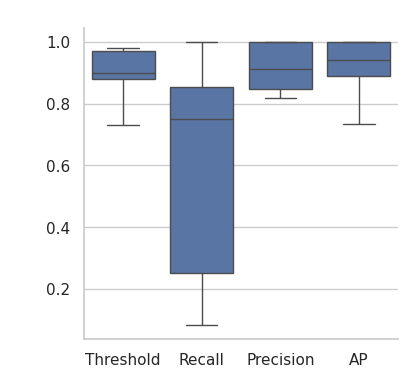

In [ ]:
box_plot(toy_th, whis=(0, 100), height=4)

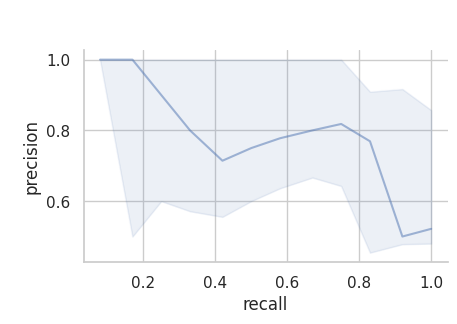

In [ ]:
plot_pr(toy_kpi, aspect=1.5, recall_round=2)

## A realistic example: credit card fraud

Toy data is too small to show what bootstrap is really for. Here we use the public credit-card-fraud dataset (492 frauds out of 284,807 transactions — 0.17% positive rate, the kind of imbalance where point estimates of recall are dangerous).

We train two **CatBoost** models that differ only in how they handle the class imbalance:

- **CatBoost** — vanilla, no class weighting. Will favor the majority class.
- **CatBoost (class-balanced)** — `auto_class_weights='Balanced'`. Reweights the loss to compensate for imbalance.

Conventional wisdom says class weighting helps on imbalanced data. Bootstrap PR curves will show whether the difference is real or noise.

In [ ]:
!pip install -q kagglehub catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 12.1 MB/s eta 0:00:00


In [ ]:
import kagglehub
import os

dataset_dir = kagglehub.dataset_download('mlg-ulb/creditcardfraud')
csv_path = os.path.join(dataset_dir, 'creditcard.csv')
pdf = pd.read_csv(csv_path)

print(f"Loaded {len(pdf):,} rows, {pdf['Class'].sum()} positives "
      f"({pdf['Class'].mean()*100:.3f}%)")

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Loaded 284,807 rows, 492 positives (0.173%)


In [ ]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier

features = ['Time', 'Amount'] + [f'V{i}' for i in range(1, 29)]
X, y = pdf[features], pdf['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y,
)

model_plain = CatBoostClassifier(
    auto_class_weights=None, random_state=42, verbose=0, iterations=100,
).fit(X_train, y_train)

model_balanced = CatBoostClassifier(
    auto_class_weights='Balanced', random_state=42, verbose=0, iterations=100,
).fit(X_train, y_train)

p_plain    = model_plain.predict_proba(X_test)[:, 1]
p_balanced = model_balanced.predict_proba(X_test)[:, 1]

### Assemble the predictions DataFrame

One long-format Spark DataFrame with both models' predictions stacked. The `name` column distinguishes them; the bootstrap and metric functions then handle both in a single pass.

In [ ]:
def to_spark_df(scores, y_true, name):
    return spark.createDataFrame(pd.DataFrame({
        'prediction': scores,
        'positive':   y_true.values,           # verified fraud
        'negative':   1 - y_true.values,       # verified legit
        'unlabeled':  0,                        # this dataset has no unlabeled rows
        'name':       name,
    }))

predictions = (
    to_spark_df(p_plain,    y_test, 'CatBoost')
    .unionByName(to_spark_df(p_balanced, y_test, 'CatBoost (balanced)'))
)

predictions.groupBy('name').count().show()

+-------------------+-----+
|               name|count|
+-------------------+-----+
|           CatBoost|85443|
|CatBoost (balanced)|85443|
+-------------------+-----+



### Bootstrap, compute metrics, plot

In [ ]:
bts = bootstrap(predictions, by=['name', 'positive'], n_replicas=100)
ct  = confusion_table(bts, group_by=['name', 'replica'])
kpi = calculate_pr(ct, group_by=['name', 'replica'])

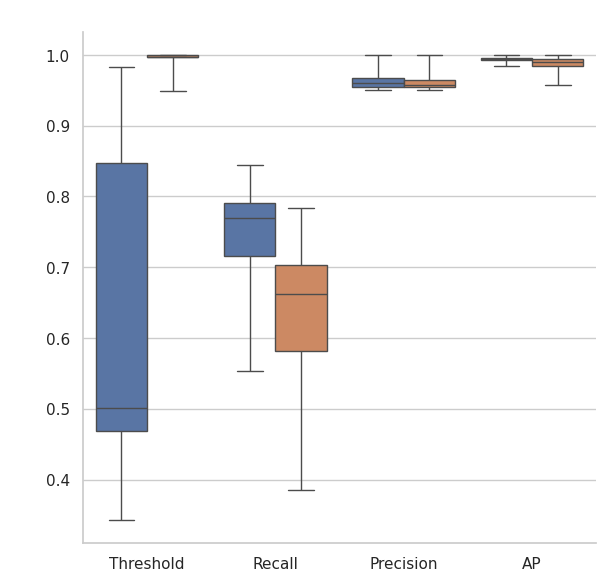

In [ ]:
ops = at(kpi, group_by=['name', 'replica'], precision=0.95).toPandas()
box_plot(ops, hue='name', whis=(0, 100), height=6)

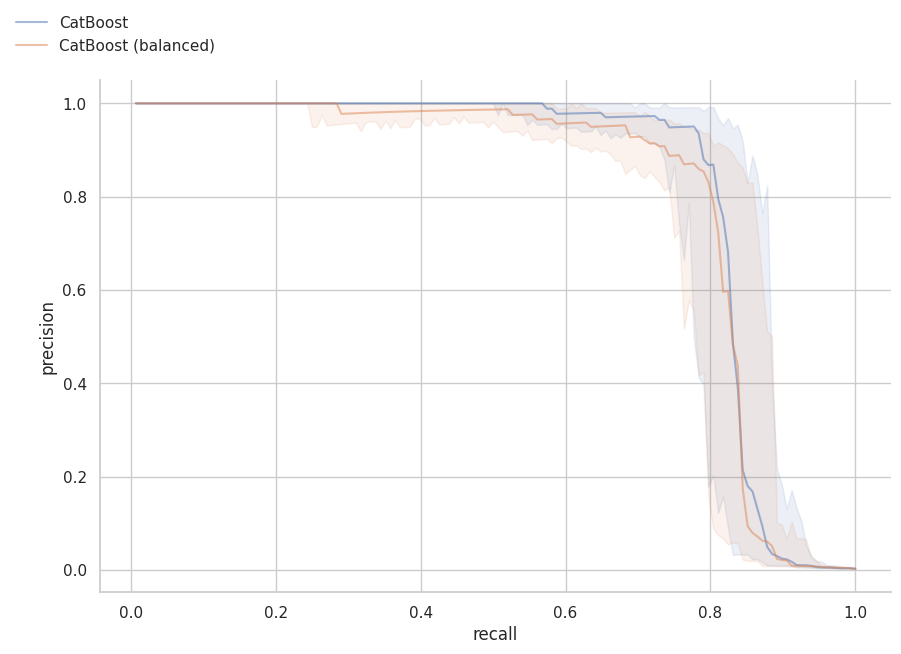

In [ ]:
plot_pr(kpi, hue='name', aspect=1.5, height=6)

### Reading the plots

The box plot shows the distribution, across 100 bootstrap replicas, of the operating point at target precision = 0.95: the threshold needed, and the recall and average precision achieved.

The PR curves show the full precision-recall trade-off with a 90% confidence band — wider where the data is thin (high recall, where false positives accumulate), narrower where positives are dense.

If the boxes for the two models overlap heavily on recall and the bands overlap heavily on the PR plot, the apparent advantage of one model over the other is within the noise of the test set. If they separate cleanly, you have a real effect.

## Beyond PR: the same pattern, any metric

The PR machinery above is one application. The bootstrap output is a long-format DataFrame; any aggregation `groupBy('replica').agg(...)` gives you a distribution of any metric.

A quick AUC example, in a few lines:

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# AUC per replica per model.
# Spark's BinaryClassificationEvaluator wants a single 'label' column, so we
# derive it from `positive` (and drop `unlabeled` rows since AUC is not defined
# for them).
labeled = (
    bts.filter(F.col('unlabeled') == 0)
       .withColumn('label', F.col('positive').cast('double'))
)

evaluator = BinaryClassificationEvaluator(
    labelCol='label', rawPredictionCol='prediction', metricName='areaUnderROC',
)

auc_rows = []
for (name, replica), pdf_group in (
    labeled.select('name', 'replica', 'label', 'prediction')
           .toPandas()
           .groupby(['name', 'replica'])
):
    auc_rows.append({
        'name': name,
        'replica': replica,
        'auc': evaluator.evaluate(spark.createDataFrame(pdf_group)),
    })

auc_df = pd.DataFrame(auc_rows)
auc_df.groupby('name')['auc'].describe()[['mean', 'std', '25%', '50%', '75%']].round(4)

The mean and quartile spread across replicas give you AUC ± its bootstrap CI. The same recipe works for F1, calibration error, Brier score, expected calibration error — any function of predictions and labels.

(For very large data, swap the Python loop above for a fully Spark-native AUC computation grouped by replica — `BinaryClassificationEvaluator` does not natively group, but it is easy enough to write the trapezoidal AUC over the confusion table directly. The bootstrap structure remains the same.)

## Summary

Three ideas worth taking away:

1. **Single numbers lie.** Recall = 0.61 says nothing about whether you would have seen 0.55 or 0.67 on a slightly different test set. Bootstrap turns that hidden uncertainty into a visible band.

2. **Spark laziness defeats naive bootstrap.** Materialize replicas once with `checkpoint()`, or your metrics will silently disagree with each other. The `bootstrap()` function above is small but every line of it is load-bearing.

3. **The pattern generalizes.** Replicas in, metrics out. Anything you can compute groupby `replica` becomes a distribution with a CI. PR curves are the demo; pick your favorite metric and the same recipe applies.